# Обнаружение глаукомы по снимкам глазного дна

##### Датасет: Hillel Yaffe Glaucoma Dataset (HYGD)
##### Источник: PhysioNet

## Введение

**Глаукома** - это группа заболеваний глаз, характеризующихся повреждением зрительного нерва, вызванным повышенным внутриглазным давлением.

Ранняя диагностика важна, так как потеря зрения при глаукоме **необратима**.

**Фотография глазного дна** - распространенный неинвазивный метод скрининга, который используют офтальмологи для выявления признаков глаукомы:

- Экскавация диска зрительного нерва (увеличение чаши диска)
- Истончение нейроретинального ободка
- Кровоизлияния в области диска зрительного нерва



## Разведочный анализ данных

#### Загрузка модулей и библиотек, датасета

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os

In [ ]:
df = pd.read_csv('data/Labels.csv')
df.head()

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 747 entries, 0 to 746
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Image Name     747 non-null    str    
 1   Patient        747 non-null    int64  
 2   Label          747 non-null    str    
 3   Quality Score  747 non-null    float64
 4   Unnamed: 4     0 non-null      float64
dtypes: float64(2), int64(1), str(2)
memory usage: 29.3 KB


### Распределение классов

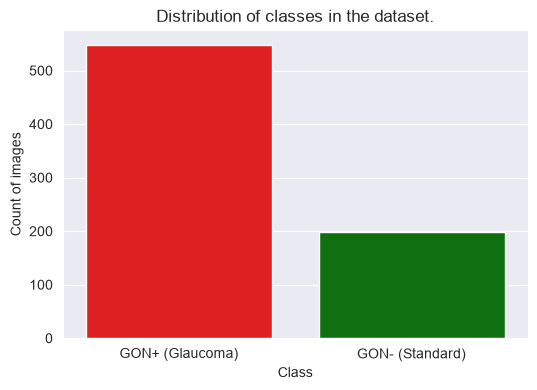

In [31]:
class_counts = df['Label'].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette=["red", "green"])
plt.title("Distribution of classes in the dataset.")
plt.xlabel("Class")
plt.ylabel("Count of images")
plt.xticks([1, 0], ["GON- (Standard)", "GON+ (Glaucoma)"])
plt.show()

#### Вывод
Изображений с глаукомой гораздо больше - это нужно будет учесть при построении модели.


#### Примеры изображений с глаукомой и без

In [26]:
# Separating images to classes.
gon_plus = df[df['Label'] == 'GON+']['Image Name'].values
gon_minus = df[df['Label'] == 'GON-']['Image Name'].values

In [27]:
def display_samples(n_samples=5):
    """Display sample fundus images with and without glaucoma.

    Args:
        n_samples: int - count of examples
    Returns:
        None
    """

    fig, axes = plt.subplots(2, n_samples, figsize=(15, 6))

    # Showing n_samples of gon+.
    for i in range(n_samples):
        img_path = f"data/Images/{gon_plus[i]}"
        img = Image.open(img_path)
        axes[0, i].imshow(img)
        axes[0, i].set_title(f"GON+\n{gon_plus[i]}")
        axes[0, i].axis("off")

    # Showing n_samples of gon-.
    for i in range(n_samples):
        img_path = f"data/Images/{gon_minus[i]}"
        img = Image.open(img_path)
        axes[1, i].imshow(img)
        axes[1, i].set_title(f"GON-\n{gon_minus[i]}")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()

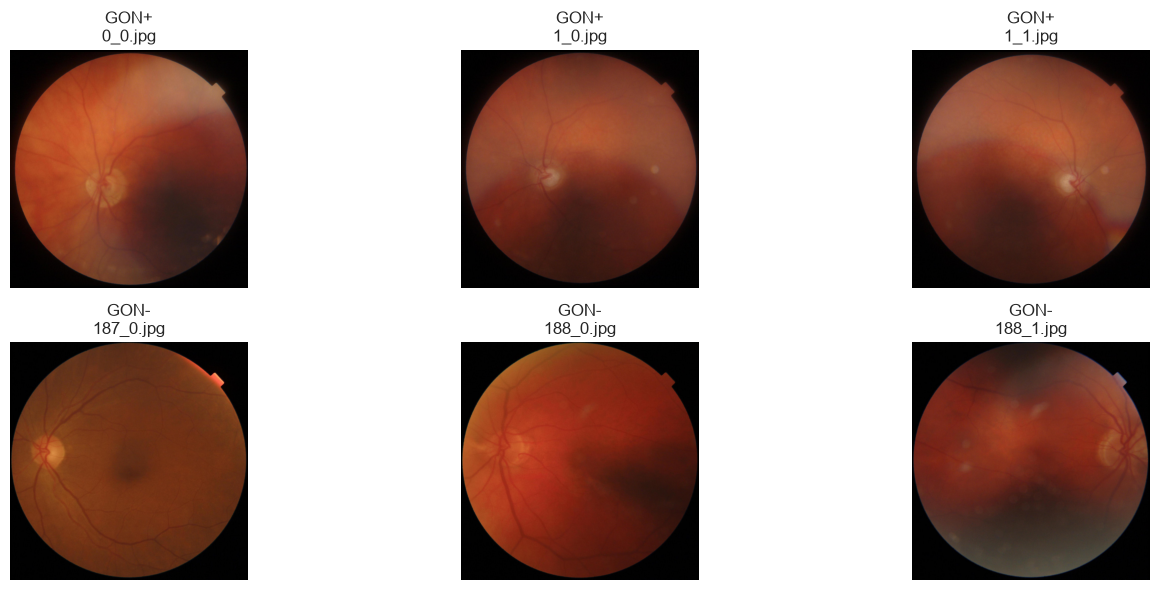

In [29]:
display_samples(3)

### Изучение качества фотографий

Проверяю гипотезу, что качество фотографий с глаукомой и без одинаково и не повлияет на решения модели.

Quality Score Statistics:
count    747.000000
mean       5.904311
std        1.007189
min        2.040000
25%        5.365000
50%        6.180000
75%        6.630000
max        7.690000
Name: Quality Score, dtype: float64

=== Mean Quality Score by Class ===
           mean       std   min   max
Label                                
GON+   5.844088  1.045786  2.04  7.69
GON-   6.070151  0.873479  3.20  7.68


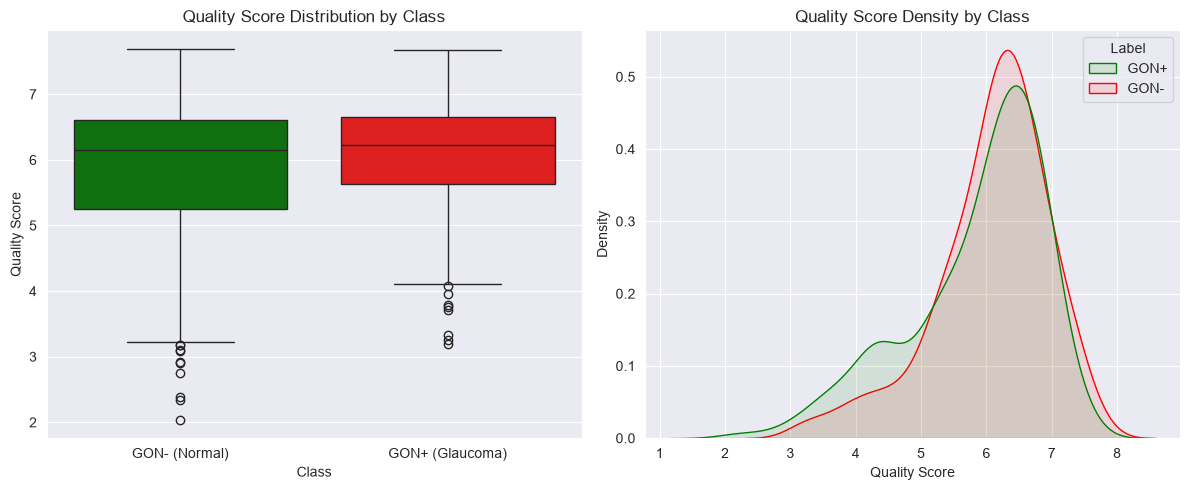

In [49]:
print("Quality Score Statistics:")
print(df["Quality Score"].describe())

print("\n=== Mean Quality Score by Class ===")
quality_stats = df.groupby("Label")["Quality Score"].agg(["mean", "std", "min", "max"])
print(quality_stats)

# Quality distribution by class
plt.figure(figsize=(12, 5))

# Boxplot - shows median, spread and outliers
plt.subplot(1, 2, 1)
sns.boxplot(
    x="Label",
    y="Quality Score",
    data=df,
    hue="Label",
    palette=["green", "red"],
    legend=False
)
plt.title("Quality Score Distribution by Class")
plt.xlabel("Class")
plt.ylabel("Quality Score")
plt.xticks([0, 1], ["GON- (Normal)", "GON+ (Glaucoma)"])

# Kdeplot - shows distribution shape
plt.subplot(1, 2, 2)
sns.kdeplot(
    data=df,
    x="Quality Score",
    hue="Label",
    palette=["green", "red"],
    fill=True,
    alpha=0.1,
    common_norm=False
)
plt.title("Quality Score Density by Class")
plt.xlabel("Quality Score")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

##### Использование U теста Манн-Уитни

In [71]:
from scipy.stats import mannwhitneyu

gon_plus_q = df[df["Label"] == "GON+"]["Quality Score"]
gon_minus_q = df[df["Label"] == "GON-"]["Quality Score"]

stat, p_value = mannwhitneyu(gon_plus_q, gon_minus_q)
print(f"Mann-Whitney U test: p = {p_value:.4f}")

if p_value < 0.05:
    print("Significant difference in quality between classes (p < 0.05)")
else:
    print("No significant difference (p > 0.05) - quality is not a confounder")

Mann-Whitney U test: p = 0.0540
No significant difference (p > 0.05) - quality is not a confounder


##### Вывод
Распределение качества изображений примерно одинаково, так что на работу модели это влиять не будет. В целом, изображения имеют среднее качество - около 6 баллов. Фотографий с супер-качеством - больше 8 баллов не наблюдается. Тогда как, размытые - меньше 3 баллов - присутствуют.

Проверка гипотезы U-тестом Манн-Уитни подтверждает, что разница статистиески незначимая.

## Анализ размеров изображений

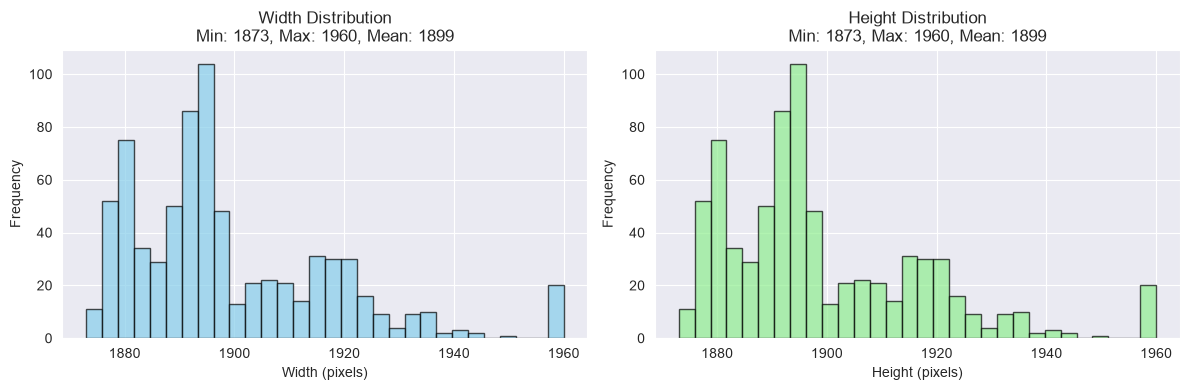

Unique resolutions: 69
Most common: (1894, 1894)


In [61]:
# Loading all images and computing sizes.
sizes = []
for f in df["Image Name"]:
    with Image.open(f"data/Images/{f}") as img:
        sizes.append(img.size)

w, h = zip(*sizes)

# Building Distribution Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(w, bins=30, color="skyblue", edgecolor="black", alpha=0.7)
axes[0].set_title(f"Width Distribution\nMin: {min(w)}, Max: {max(w)}, Mean: {sum(w)/len(w):.0f}")
axes[0].set_xlabel("Width (pixels)")
axes[0].set_ylabel("Frequency")

axes[1].hist(h, bins=30, color="lightgreen", edgecolor="black", alpha=0.7)
axes[1].set_title(f"Height Distribution\nMin: {min(h)}, Max: {max(h)}, Mean: {sum(h)/len(h):.0f}")
axes[1].set_xlabel("Height (pixels)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Unique resolutions
print(f"Unique resolutions: {len(set(sizes))}")
print(f"Most common: {max(set(sizes), key=sizes.count)}")

##### Вывод
Размеры изобржаений сильно разбросаны. Следовательно до обучения модели их нужно будет привести к единому размеру.

Также устанавливается, что все изображения квадратные - ширина и высота не отличаются нигде.

## Анализ разнообразия пациентов

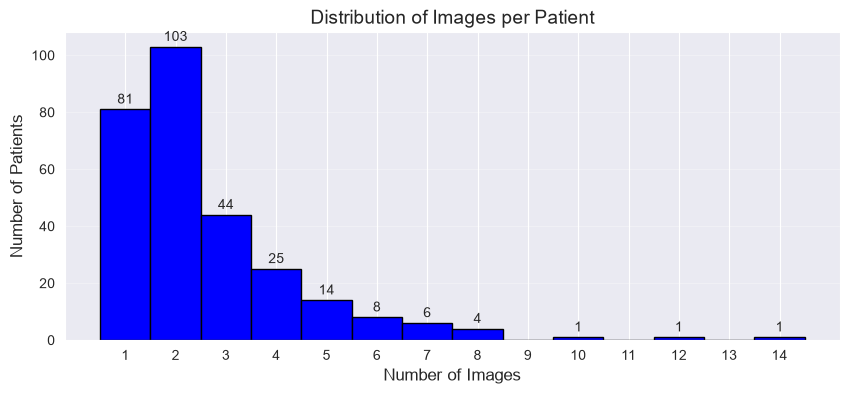

In [67]:
# Counting images per patient.
patient_counts = df["Patient"].value_counts().sort_values(ascending=False)

# Distribution of images per patient.
plt.figure(figsize=(10, 4))
plt.hist(patient_counts, bins=range(1, patient_counts.max()+2),
         color="blue", edgecolor="black", alpha=1, align="left")
plt.title("Distribution of Images per Patient", fontsize=14)
plt.xlabel("Number of Images", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)
plt.xticks(range(1, patient_counts.max()+1))
plt.grid(axis="y", alpha=0.3)

# Adding text for each bin.
for i, count in enumerate(sorted(patient_counts.unique())):
    n_patients = sum(patient_counts == count)
    plt.text(count, n_patients + 1, str(n_patients), ha="center", va="bottom", fontsize=10)

plt.show()

In [68]:
# How many unique patients?
unique_patients = df["Patient"].nunique()
total_images = len(df)

print(f"Total images: {total_images}")
print(f"Unique patients: {unique_patients}")
print(f"Average images per patient: {total_images / unique_patients:.2f}")


Total images: 747
Unique patients: 288
Average images per patient: 2.59


##### Вывод
Крайне мало пациентов имеют всего одно изображение. В среднем их 2.5 на каждого человека. Изображения одного и того же пациента будут рассматирваться как независимые, потому что имеют разные ракурсы, в основном, что расширяет датасет различными объектами, а может это и вовсе разные глаза.

## Анализ яркости изображений

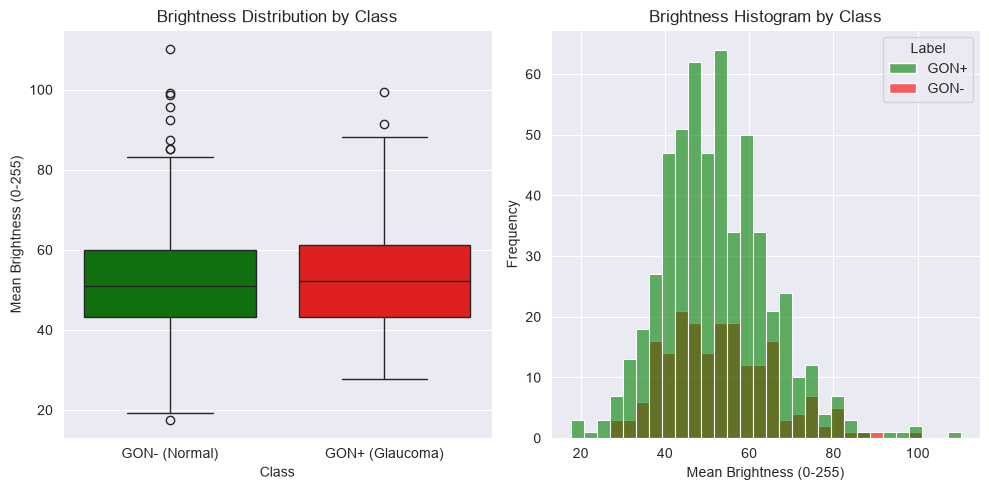


Brightness Statistics by Class
            mean        std        min         max
Label                                             
GON+   52.097493  12.805553  17.604233  110.148961
GON-   53.124012  13.068089  27.707251   99.521676


In [74]:
plt.figure(figsize=(10, 5))

# Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(
    x="Label",
    y="Brightness",
    data=df,
    hue="Label",
    palette=["green", "red"],
    legend=False
)
plt.title("Brightness Distribution by Class")
plt.xlabel("Class")
plt.ylabel("Mean Brightness (0-255)")
plt.xticks([0, 1], ["GON- (Normal)", "GON+ (Glaucoma)"])

# Histogram
plt.subplot(1, 2, 2)
sns.histplot(
    data=df,
    x="Brightness",
    hue="Label",
    palette=["green", "red"],
    bins=30,
    alpha=0.6
)
plt.title("Brightness Histogram by Class")
plt.xlabel("Mean Brightness (0-255)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

print("\nBrightness Statistics by Class")
print(df.groupby("Label")["Brightness"].agg(["mean", "std", "min", "max"]))

#### Визуализация самых ярких и темных изображений

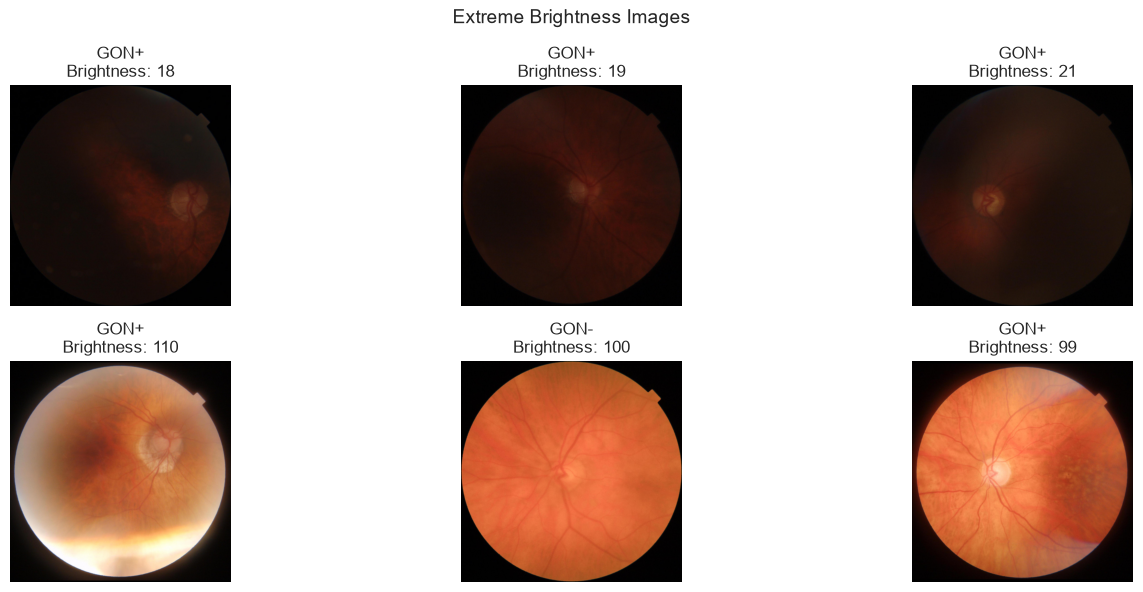

In [76]:
def get_brightness(filename):
    img = Image.open(f"data/Images/{filename}").convert("L")
    return np.mean(np.array(img))

df["Brightness"] = df["Image Name"].apply(get_brightness)

darkest = df.nsmallest(3, "Brightness")
brightest = df.nlargest(3, "Brightness")

fig, axes = plt.subplots(2, 3, figsize=(15, 6))

# Darkest
for i, (idx, row) in enumerate(darkest.iterrows()):
    img = Image.open(f"data/Images/{row['Image Name']}")
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"{row['Label']}\nBrightness: {row['Brightness']:.0f}")
    axes[0, i].axis("off")
axes[0, 0].set_ylabel("Darkest", fontsize=12)

# Brightest
for i, (idx, row) in enumerate(brightest.iterrows()):
    img = Image.open(f"data/Images/{row['Image Name']}")
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"{row['Label']}\nBrightness: {row['Brightness']:.0f}")
    axes[1, i].axis("off")
axes[1, 0].set_ylabel("Brightest", fontsize=12)

plt.suptitle("Extreme Brightness Images", fontsize=14)
plt.tight_layout()
plt.show()

#### Вывод
Поскольку изображения сильно различаются по яркости, а судить о болезнм стоит по анатомическим признакам, а не по яркости, то во время построения модели проведем аугментацию, нормализацию, стандартизацию.

## Итоговый вывод
В ходе EDA выявлен дисбаланс классов (GON+ 73%, GON- 27%), поэтому при обучении будем использовать взвешенную функцию потерь. Качество изображений между классами не различается. Добавим аугментацию яркости, чтобы модель не выучила ложную связь между освещением и диагнозом.

Размеры изображений сильно разбросаны - все будут приведены к единому размеру - среднему по всем кадрам. Поскольку у пациентов с глаукомой в среднем больше снимков (2.95 против 1.95), а один пациент имеет 14 снимков, принято решение ограничить выборку 5 лучшими по качеству изображениями на пациента, чтобы избежать переобучения.